## Formative Assessment: Supervised Learning

## Objective:
*  The goal of this project is to apply supervised machine learning techniques to the breast cancer dataset in order to build and evaluate classification models that can accurately predict whether a tumor is malignant or benign.
*  The project also aims to compare the performance of different algorithms and understand the impact of preprocessing techniques such as feature scaling on model accuracy.

## Dataset
We are using the breast cancer dataset available in sklearn

## Steps Involved
* Data Collection
* Import Libraries
* Data Cleaning & Preprocessing
* Exploratory Data Analysis (EDA)
* Feature Engineering & Selection
* Model Building
* Model Evaluation
* Testing the Model

In [1]:
### step 1 Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

## Data collection
The breast_cancer_dataset is loaded from the sklearn libray using the load_breast_cancer() function.
This dataset is a built-in dataset provided by sklearn and is widely used for classification tasks.

It contains 569 rows and 31 columns:

- 30 features (numerical measurements of cell nuclei, such as radius, texture, perimeter, area, smoothness, etc.)
- 1 target variable (diagnosis)


In [9]:
# Step 2 :Load the dataset
from sklearn.datasets import load_breast_cancer
data= load_breast_cancer()

In [11]:
# Step 3:Convert the dataset into a DataFrame (table)
import pandas as pd

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


* The dataset was converted into a DataFrame using pandas for easier manipulation and analysis.
* The feature values were assigned appropriate column names using feature_names, and the target variable was added as a separate column. 
* The head() function was used to preview the dataset.

## Data Cleaning & Preprocessing
* Check missing values
* Check data types
* No major cleaning required (dataset is clean)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [14]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [16]:
df.shape

(569, 31)

In [17]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [18]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Length: 569, dtype: bool

In [19]:
print(df.duplicated().sum())

0


In [20]:
df.shape

(569, 31)

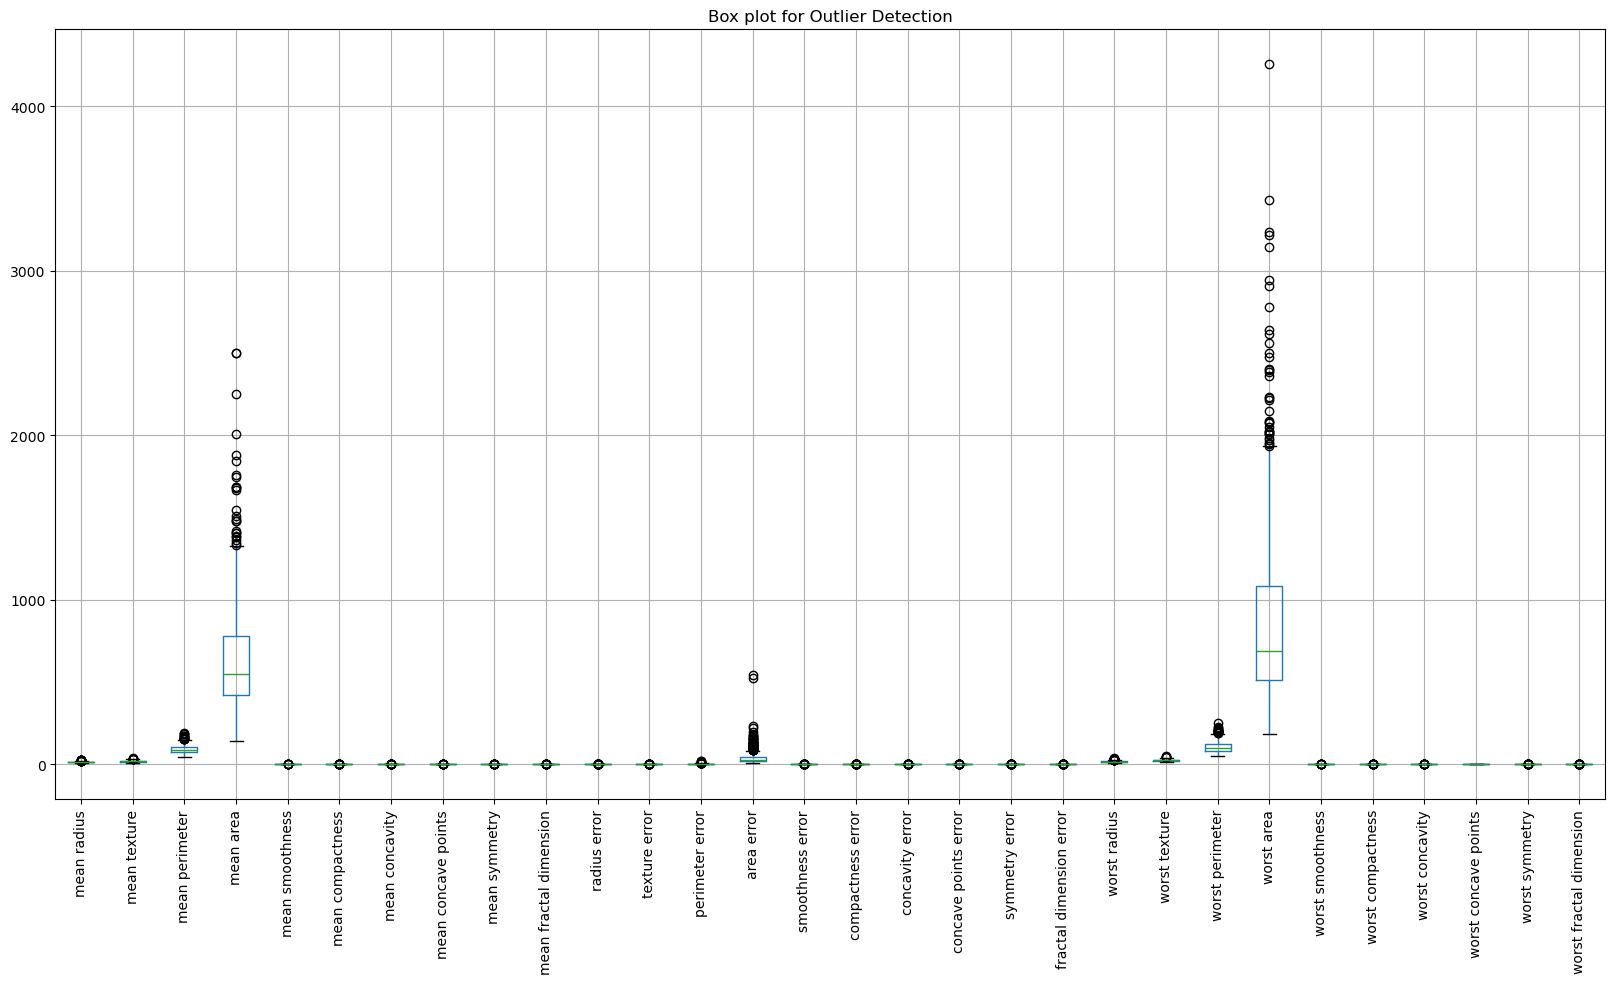

In [45]:
# For finding Outliers using BoxPlot diagram
import matplotlib.pyplot as plt
plt.figure(figsize = (20,10))
df.drop("target",axis = 1).boxplot(rot=90)
plt.title("Box plot for Outlier Detection")
plt.show()

## Insights

* The boxplot shows the distribution of all numerical features in the dataset.
* Several features display points outside the whiskers, indicating potential outliers.
* The spread of values varies significantly across features, showing differences in scale and variance.
* Some features have skewed distributions, where data is not evenly spread.
* The presence of many “outliers” across multiple features suggests they may be natural variations rather than errors.

Here , we didn't handle the Outliers Because:

* The dataset represents real-world medical data, where extreme values can be meaningful.
* Removing outliers may lead to loss of important information.
* The detected outliers are likely due to natural biological variations, not data entry mistakes.
* Many machine learning models used (like Random Forest and Decision Tree) are robust to outliers.


 Instead of removing outliers, **feature scaling** was applied to reduce the impact of different value ranges.
Keeping the data intact helps in maintaining model accuracy and reliability.

In [29]:
# Split data into features and target
from sklearn.model_selection import train_test_split
X = df.drop("target", axis=1)  #Features
y = df["target"]  #Target

In [30]:
# Train-test split (80% train,20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
# Standard features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report

## Algorithms Implementation:

In [47]:
#Logistic Regression accuracy
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=10000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



#### Logistic Regression

* Logistic Regression is a linear classification algorithm that predicts the probability of a data point belonging to a particular class using a sigmoid function. 
* It transforms the output into values between 0 and 1, which are then used for classification.
* It works well for binary classification problems like this dataset and performs efficiently when features are properly scaled.

In [39]:
# Decision tree classifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



####  Decision Tree Classifier
* Decision Tree is a non-linear algorithm that splits the dataset into branches based on feature values. 
* It creates a tree-like structure where each node represents a decision rule and each leaf node represents a class label.
* It is easy to interpret and can capture complex relationships between features without requiring feature scaling.

In [40]:
# Random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



#### Random Forest Classifier
* Random Forest is an ensemble learning method that builds multiple decision trees and combines their outputs to make a final prediction.
* It reduces overfitting by averaging the results of many trees.
* It provides high accuracy and handles large datasets with many features effectively, making it suitable for this dataset.

In [41]:
# Support Vector Machine
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



#### Support Vector Machine
* Support Vector Machine is a powerful algorithm that finds the optimal hyperplane that separates data points of different classes with maximum margin.
* It performs well in high-dimensional datasets like this one and is effective when there is a clear margin of separation between classes

In [42]:
# K-nearest neighbours
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



#### K-nearest neighbours
* k-NN is a distance-based algorithm that classifies a data point based on the majority class of its nearest neighbors.
* It is simple and effective for smaller datasets and works well when the data is properly scaled.

## Model Comparison

In [43]:
# Model comparison Table
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
3                  SVM  0.982456
0  Logistic Regression  0.973684
2        Random Forest  0.964912
1        Decision Tree  0.947368
4                  KNN  0.947368


From the comparison table, it can be observed that the Support Vector Machine (SVM) achieved the highest accuracy among all the models, making it the best-performing algorithm for this dataset.

On the other hand, the Decision Tree and k-Nearest Neighbors (KNN) showed comparatively lower accuracy, indicating weaker performance. This may be due to overfitting in Decision Tree and sensitivity to data distribution in KNN.

## Conclusion

In this project, multiple supervised learning algorithms were applied to the breast cancer dataset to classify tumors as malignant or benign. The dataset was preprocessed using feature scaling to ensure fair contribution of all features, and five classification models were implemented and evaluated.

Among all the models, the Support Vector Machine (SVM) and Random Forest Classifier performed the best, achieving the highest accuracy and balanced performance across precision, recall, and F1-score. In particular, SVM showed strong generalization on the test data, making it highly effective for this high-dimensional dataset.

On the other hand, the Decision Tree Classifier showed comparatively lower performance, likely due to overfitting and its sensitivity to variations in the data.

Overall, the results demonstrate that ensemble methods and margin-based classifiers tend to perform better on this dataset, while simpler models may require careful tuning. This project highlights the importance of preprocessing, model selection, and evaluation metrics in building reliable machine learning models for real-world applications.